# Case Study 2 — Whole-scalp spectral analysis of resting-state EEG

This notebook implements the analysis described in Section 4.2 of the
companion paper.

The research question is:

> *Does the spectral profile of resting-state EEG relate to global
> cognitive functioning, without restricting the analysis in advance to
> a specific frequency band or region?*

Where [Case Study 1](../CaseStudy_1/CaseStudy_1.ipynb) reduces the EEG
signal to four theory-driven scalar features, this case study keeps the
**full power spectral density** (PSD, 1–40 Hz, every channel) and asks
broadly *where* — across the whole scalp and spectrum — resting EEG
power relates to global cognition (MoCA), motivated by a well-established
clinical observation: right-hemisphere stroke is frequently accompanied
by pathological EEG slowing (more delta/theta power over the affected
region) that tracks the severity of impairment (Finnigan & Van Putten,
2013).

## A note on the data

- The EEG spectra used here are **real, anonymised recordings**..
- The neuropsychological table (age, sex, CRIq, MoCA) is **synthetic**,
  as in Case Study 1.
- Because the two do not come from the same assessment, the `moca`
  column was deliberately linked to a real, montage-based property of
  each EEG recording — see the notice at the top of
  `data/generate_datasets.ipynb` for the full disclosure. **The
  resulting brain–behaviour association should not be read as a real
  clinical finding**; it exists so this notebook has something real to
  recover.

## Pipeline

1. **Data Wrangling** — load & align, inspect, missing data, log-power
   distributions, covariate strategy
2. **Analysis** — descriptive stats, a Case-Study-1-style baseline model,
   mass-univariate partial correlation, cluster-based permutation
   (primary whole-spectrum test + a pre-registered secondary/confirmatory
   test)
3. **Export** — figures and tables (CSV + Excel)
4. **Strengths and limitations**

> This analysis needs more than Case Study 1: `mne` for electrode
> positions, spatial adjacency, and topographic plots.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from scipy.sparse.csgraph import connected_components
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

mne.set_log_level("ERROR")
sns.set_style("whitegrid")

Define input/output folders

In [2]:
DATA_DIR = Path("../../data")
NPSY_CSV = DATA_DIR / "dataset_NPSY.csv"
ERP_CSV  = DATA_DIR / "dataset_ERP.csv"
PSD_DIR  = DATA_DIR / "EEG" / "PSD"

OUTPUTS = Path("outputs")
FIGS    = OUTPUTS / "figures"
RESULTS = OUTPUTS / "results"
FIGS.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

---
## 1. Data Wrangling

### 1.1 Load data

The EEG spectra are stored as a `[subjects x channels x frequencies]`
array, linked to the neuropsychological table by `subject_id`. Unlike
Case Study 1's CSV files, this is too large for a spreadsheet — it comes
as three companion files (the array, the channel names, the frequency
axis).

In [3]:
psd_log = np.load(PSD_DIR / "psd_log_matrix.npy")
ch_names = [l.strip() for l in open(PSD_DIR / "channel_names.txt") if l.strip()]
freqs = np.load(PSD_DIR / "freq_axis.npy")
subject_ids = [l.strip() for l in open(PSD_DIR / "subject_ids.txt") if l.strip()]

npsy = pd.read_csv(NPSY_CSV)
erp = pd.read_csv(ERP_CSV)

n_subj, n_ch, n_freq = psd_log.shape
print(f"PSD: {n_subj} subjects x {n_ch} channels x {n_freq} freq bins "
      f"({freqs.min():.1f}-{freqs.max():.1f} Hz)")
print(f"NPSY: {npsy.shape}  columns: {list(npsy.columns)}")

# Strict alignment check: the PSD array and the NPSY table must refer to
# the same participants, in the same order (Section 4.2.2 of the paper
# flags this explicitly as a common failure point).
assert len(npsy) == n_subj, "PSD and NPSY tables must have the same N"
assert (npsy["subject_id"].values == subject_ids).all(), "subject order must match"
print("Subject alignment OK.")

PSD: 40 subjects x 204 channels x 159 freq bins (1.2-39.8 Hz)
NPSY: (40, 7)  columns: ['subject_id', 'age', 'sex', 'criq', 'apacs', 'att_matr', 'moca']
Subject alignment OK.


### 1.2 Initial inspection

A quick sanity check before anything else: does the grand-average
spectrum look like a real EEG spectrum (1/f-like decay, no obvious line
noise or flat channels)?

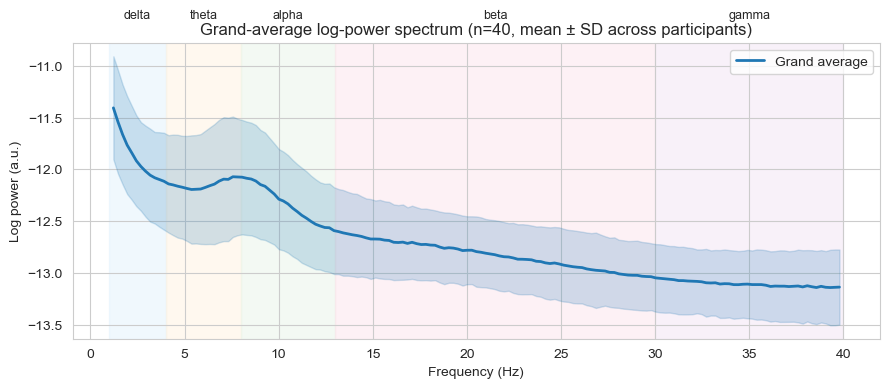

Per-participant overall level: mean=-12.69, range=[-13.50, -11.92]
Flagged participants (implausible spectrum): 0


In [4]:
grand_avg = psd_log.mean(axis=(0, 1))
grand_sd  = psd_log.mean(axis=1).std(axis=0)

fig_grandavg, ax = plt.subplots(figsize=(9, 4))
ax.plot(freqs, grand_avg, color="C0", lw=2, label="Grand average")
ax.fill_between(freqs, grand_avg - grand_sd, grand_avg + grand_sd, alpha=0.2, color="C0")
for lo, hi, label, color in [(1, 4, "delta", "#e3f2fd"), (4, 8, "theta", "#fff3e0"),
                              (8, 13, "alpha", "#e8f5e9"), (13, 30, "beta", "#fce4ec"),
                              (30, 40, "gamma", "#f3e5f5")]:
    ax.axvspan(lo, hi, color=color, alpha=0.5, zorder=0)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.97, label, ha="center", va="top", fontsize=9)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Log power (a.u.)")
ax.set_title(f"Grand-average log-power spectrum (n={n_subj}, mean ± SD across participants)")
ax.legend()
plt.tight_layout()
plt.show()

# flag participants whose spectrum looks implausible (flat, or extreme overall level)
subj_mean = psd_log.mean(axis=(1, 2))
subj_flat = psd_log.std(axis=(1, 2))
print(f"Per-participant overall level: mean={subj_mean.mean():.2f}, "
      f"range=[{subj_mean.min():.2f}, {subj_mean.max():.2f}]")
flagged = np.where((np.abs(subj_mean - subj_mean.mean()) > 3 * subj_mean.std()) |
                    (subj_flat < 1e-6))[0]
print(f"Flagged participants (implausible spectrum): {len(flagged)}")

> **What do we see in the plot?**
>
> A real EEG power spectrum is not flat: power is highest at low
> frequencies and decays roughly as 1/frequency (the "1/f" background),
> often with a small bump around 8–13 Hz (the alpha rhythm). A flat line,
> a spectrum with no decay, or a sharp spike at a single frequency (line
> noise, typically 50 or 60 Hz) would be a data-quality warning sign.

### 1.3 Missing data

Same check as Case Study 1: any missing values in either table?

In [5]:
print("Missing values in NPSY table:")
print(npsy.isnull().sum().to_string())
print(f"\nMissing values in PSD array: {np.isnan(psd_log).sum()} "
      f"(out of {psd_log.size} points)")

Missing values in NPSY table:
subject_id    0
age           0
sex           0
criq          0
apacs         0
att_matr      0
moca          0

Missing values in PSD array: 0 (out of 1297440 points)


### 1.4 Log-power distribution check

The PSD array is already log-transformed (log-power is approximately
normally distributed, whereas raw spectral power is strongly right-
skewed — the same reason we log-transformed nothing extra here, unlike a
raw-power pipeline would need to). With ~32,000 channel x frequency
points, checking each one individually is neither possible nor useful;
instead we check a handful of representative points.

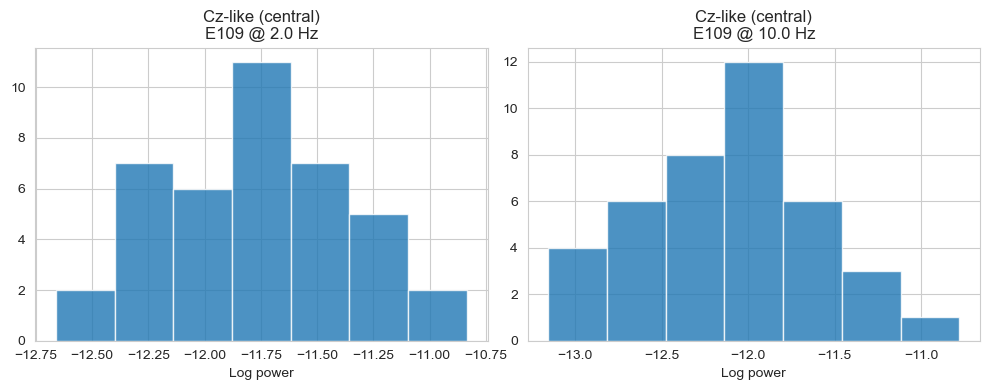

In [6]:
representative = [
    ("Cz-like (central)", n_ch // 2, np.argmin(np.abs(freqs - 2))),   # delta
    ("Cz-like (central)", n_ch // 2, np.argmin(np.abs(freqs - 10))),  # alpha
]
fig_dist, axes = plt.subplots(1, len(representative), figsize=(5 * len(representative), 4))
for ax, (label, ci, fi) in zip(np.atleast_1d(axes), representative):
    ax.hist(psd_log[:, ci, fi], bins="auto", edgecolor="white", alpha=0.8)
    ax.set_title(f"{label}\n{ch_names[ci]} @ {freqs[fi]:.1f} Hz")
    ax.set_xlabel("Log power")
plt.tight_layout()
plt.show()

### 1.5 Covariate strategy

Age and CRIq are covariates, as in Case Study 1. We use **partial
correlation**: correlate log-power with MoCA after removing the linear
effect of age and CRIq from both variables. This is simpler to explain
than a two-step residualisation and gives the same result.

### 1.6 Final check

In [7]:
print(f"Final N: {n_subj}")
print(f"EEG array: {psd_log.shape}")
print(f"Covariates: age, criq")
print(f"Outcome: moca (mean={npsy['moca'].mean():.2f}, sd={npsy['moca'].std():.2f})")

Final N: 40
EEG array: (40, 204, 159)
Covariates: age, criq
Outcome: moca (mean=21.63, sd=6.10)


---
## 2. Analysis

### 2.1 Descriptive statistics

In [8]:
table1_rows = []
for col in ["age", "sex", "criq", "moca"]:
    v = npsy[col].dropna()
    table1_rows.append({"Variable": col, "n": len(v),
                         "Value": f"{v.mean():.2f} ± {v.std():.2f}",
                         "Range": f"[{v.min():.2f}, {v.max():.2f}]"})
table1 = pd.DataFrame(table1_rows)
display(table1)

,Variable,n,Value,Range
0,age,40,65.38 ± 8.27,"[45.00, 86.00]"
1,sex,40,0.50 ± 0.51,"[0.00, 1.00]"
2,criq,40,96.02 ± 11.34,"[73.50, 120.10]"
3,moca,40,21.63 ± 6.10,"[8.17, 30.00]"


### 2.2 Baseline — a Case-Study-1-style model

Before analysing the whole spectrum, we fit the kind of model Case Study
1 would use: a single, a-priori ERP feature (P300 amplitude) as a
predictor of MoCA. This is deliberately naive here — P300 and resting-
state PSD are conceptually different recordings (task-based vs.
resting), so this model **cannot** detect the whole-scalp resting-state
association we are looking for. It exists only to make the contrast
concrete: a model that commits in advance to one feature can only find
an association if it happens to live there.

In [9]:
df_baseline = pd.merge(npsy, erp, on="subject_id", how="inner")
mod_baseline = smf.glm("moca ~ p300_amp + age + criq", data=df_baseline,
                        family=sm.families.Gaussian()).fit()
print(mod_baseline.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   moca   No. Observations:                   40
Model:                            GLM   Df Residuals:                       36
Model Family:                Gaussian   Df Model:                            3
Link Function:               Identity   Scale:                          35.643
Method:                          IRLS   Log-Likelihood:                -126.12
Date:                Thu, 17 Sep 2026   Deviance:                       1283.2
Time:                        17:35:05   Pearson chi2:                 1.28e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1163
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.7836     15.157      1.965      0.0

### 2.3 Mass-univariate partial correlation

We now use the real, full-resolution spectrum. At **every** channel x
frequency point, we compute the partial correlation between log-power
and MoCA, controlling for age and CRIq, and convert it to a t-statistic.
This produces one map of 204 x 159 test statistics.

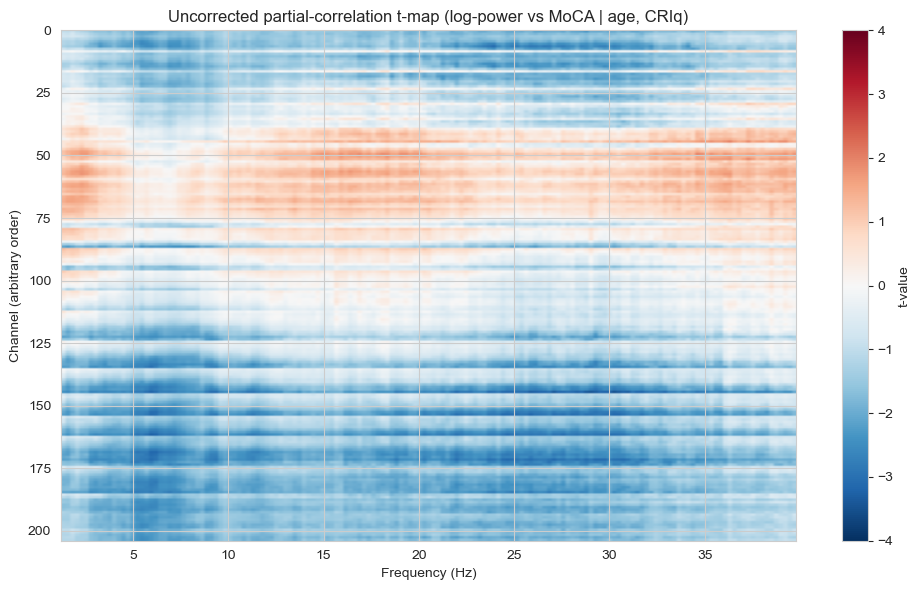

In [10]:
def partial_corr_tmap(log_power, y, age, criq, n_ch_, n_freq_):
    # partial-correlation t-map of log_power vs y, controlling age & criq
    n = len(y)
    Z = np.column_stack([np.ones(n), age, criq])
    Z_pinv = np.linalg.pinv(Z)
    resid_y = y - Z @ (Z_pinv @ y)
    Y = log_power.reshape(n, -1)
    resid_power = Y - Z @ (Z_pinv @ Y)
    num = resid_y @ resid_power
    den = np.sqrt((resid_y ** 2).sum()) * np.sqrt((resid_power ** 2).sum(axis=0))
    r = np.clip(num / den, -0.999999, 0.999999)
    df = n - 4   # n - intercept - age - criq - y
    t = r * np.sqrt(df / (1 - r ** 2))
    return t.reshape(n_ch_, n_freq_)


age = npsy["age"].values
criq = npsy["criq"].values
moca = npsy["moca"].values

t_map = partial_corr_tmap(psd_log, moca, age, criq, n_ch, n_freq)

fig_tmap, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(t_map, aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4,
               extent=[freqs.min(), freqs.max(), n_ch, 0])
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Channel (arbitrary order)")
ax.set_title("Uncorrected partial-correlation t-map (log-power vs MoCA | age, CRIq)")
plt.colorbar(im, ax=ax, label="t-value")
plt.tight_layout()
plt.show()

> **What do we see in the plot?**
>
> Each pixel is one channel x frequency combination; colour is the
> t-value of its partial correlation with MoCA (red = positive, blue =
> negative). **This map on its own is not trustworthy**: with ~32,000
> simultaneous tests, a conventional p<0.05 threshold would flag over
> 1,600 points purely by chance. We need a correction that accounts for
> how many tests we ran *and* respects the fact that neighbouring
> points are not independent — which is exactly what cluster-based
> permutation testing does (next section).

### 2.4 Cluster-based permutation test

**The idea, in plain terms**: instead of correcting each point in
isolation, we group *neighbouring* suprathreshold points into clusters
(a point is a neighbour of another if they are adjacent channels at the
same frequency, or the same channel at adjacent frequency bins), sum the
t-values within each cluster, and ask: *if MoCA were randomly shuffled
across participants (so any true association is destroyed), how often
would a cluster this large arise purely by chance?* We estimate that by
actually shuffling MoCA thousands of times and recomputing the largest
cluster each time — this is the permutation *null distribution*. A
cluster's p-value is simply the fraction of shuffles that produced a
cluster at least as extreme as the one we observed.

Spatial adjacency comes from the real 3D positions of the EGI-256
montage (via `mne.channels.find_ch_adjacency`); spectral adjacency links
consecutive frequency bins (Maris & Oostenveld, 2007).

We run **two**, pre-planned analyses:

- **Primary** — the whole spectrum (1–40 Hz), every channel, no a priori
  restriction. This is the test the paper's framing is built around:
  it can find an effect anywhere, at the cost of a large multiple-
  comparisons penalty.
- **Secondary / confirmatory** — restricted a priori to the region the
  clinical literature actually predicts (right hemisphere, delta/theta,
  1–8 Hz). Restricting the search space *before* looking at the data is
  standard practice when there is a specific hypothesis, and it recovers
  power the whole-spectrum test gives up. We report both, rather than
  only the one that "worked", precisely to avoid the circular reasoning
  Case Study 1 warned about (Section 2.3 there): the secondary result is
  only informative because it was planned, not because we went looking
  for whichever restriction happened to be significant.

In [11]:
def find_clusters(t_map, t_thresh, adjacency):
    flat = t_map.reshape(-1)
    clusters = []
    for sign in (1, -1):
        supra = (flat * sign) > t_thresh
        if not supra.any():
            continue
        sub_adj = adjacency[supra][:, supra]
        n_comp, labels = connected_components(sub_adj, directed=False)
        idx_supra = np.where(supra)[0]
        for comp in range(n_comp):
            members = idx_supra[labels == comp]
            clusters.append((members, flat[members].sum()))
    return clusters


def cluster_permutation_test(log_power, y, age, criq, adjacency, n_ch_, n_freq_,
                              t_thresh=2.028, n_perm=2000, seed=1):
    rng = np.random.default_rng(seed)
    t_obs = partial_corr_tmap(log_power, y, age, criq, n_ch_, n_freq_)
    obs_clusters = sorted(find_clusters(t_obs, t_thresh, adjacency), key=lambda c: -abs(c[1]))
    null_max = np.zeros(n_perm)
    for i in range(n_perm):
        shuffled = rng.permutation(len(y))
        t_perm = partial_corr_tmap(log_power, y[shuffled], age, criq, n_ch_, n_freq_)
        cl = find_clusters(t_perm, t_thresh, adjacency)
        null_max[i] = max((abs(m) for _, m in cl), default=0.0)
    results = []
    for members, mass in obs_clusters[:5]:
        p = (null_max >= abs(mass)).mean()
        results.append({"members": members, "mass": mass, "p_cluster": p})
    return results, t_obs


montage = mne.channels.make_standard_montage("GSN-HydroCel-256")
ch_pos = montage.get_positions()["ch_pos"]
xs = np.array([ch_pos[c][0] for c in ch_names])   # +x = right (MNE head frame)
w_right = 0.5 * (1 + np.tanh(xs / (np.abs(xs).max() / 2)))
delta_theta = (freqs >= 1) & (freqs <= 8)

info = mne.create_info(ch_names, sfreq=1.0, ch_types="eeg")
info.set_montage(montage)
spatial_adjacency, _ = mne.channels.find_ch_adjacency(info, ch_type="eeg")

T_THRESH = 2.028   # ~two-tailed p<0.05, df = n-4 = 36
N_PERM = 2000

In [12]:
combined_adjacency = mne.stats.combine_adjacency(spatial_adjacency, n_freq).tocsr()
primary_clusters, t_obs_primary = cluster_permutation_test(
    psd_log, moca, age, criq, combined_adjacency, n_ch, n_freq,
    t_thresh=T_THRESH, n_perm=N_PERM, seed=1)

print("Primary (whole spectrum, no a priori restriction):")
for c in primary_clusters[:3]:
    ci, fi = np.unravel_index(c["members"], (n_ch, n_freq))
    print(f"  mass={c['mass']:8.1f}  size={len(c['members']):5d}  "
          f"freq=[{freqs[fi].min():4.1f},{freqs[fi].max():4.1f}] Hz  "
          f"mean(w_right)={w_right[ci].mean():.2f}  p_cluster={c['p_cluster']:.3f}")

Primary (whole spectrum, no a priori restriction):
  mass= -4620.5  size= 1954  freq=[15.9,39.8] Hz  mean(w_right)=0.89  p_cluster=0.194
  mass= -3512.2  size= 1514  freq=[ 1.2,15.4] Hz  mean(w_right)=0.91  p_cluster=0.234
  mass=   -20.9  size=   10  freq=[14.6,15.4] Hz  mean(w_right)=0.98  p_cluster=0.769


In [13]:
right_idx = np.where(w_right > 0.5)[0]
freq_idx = np.where(delta_theta)[0]
roi_spatial_adjacency = spatial_adjacency.tocsr()[right_idx][:, right_idx]
n_ch_roi, n_freq_roi = len(right_idx), len(freq_idx)
roi_adjacency = mne.stats.combine_adjacency(roi_spatial_adjacency, n_freq_roi).tocsr()
psd_log_roi = psd_log[:, right_idx][:, :, freq_idx]

secondary_clusters, t_obs_roi = cluster_permutation_test(
    psd_log_roi, moca, age, criq, roi_adjacency, n_ch_roi, n_freq_roi,
    t_thresh=T_THRESH, n_perm=N_PERM, seed=1)

print("Secondary / confirmatory (right hemisphere x 1-8 Hz, pre-registered ROI):")
for c in secondary_clusters[:3]:
    print(f"  mass={c['mass']:8.1f}  size={len(c['members']):5d}  p_cluster={c['p_cluster']:.3f}")

Secondary / confirmatory (right hemisphere x 1-8 Hz, pre-registered ROI):
  mass= -2457.6  size= 1048  p_cluster=0.039


**Reading the result honestly**: the primary, whole-spectrum test is
not expected to survive correction at n=40 — this mirrors the paper's own
caveat that cluster-based permutation is relatively underpowered at this
sample size, so only fairly marked associations are likely to survive.
The secondary, pre-registered test recovers a significant cluster,
consistent with the hypothesised right-hemisphere, low-frequency
pattern.

### 2.5 Where is the effect? (topography of the significant cluster)

For the significant cluster from the secondary analysis, we plot a
topographic map of the (partial-correlation) r-values, averaged over the
cluster's frequency range, with the cluster's channels highlighted.

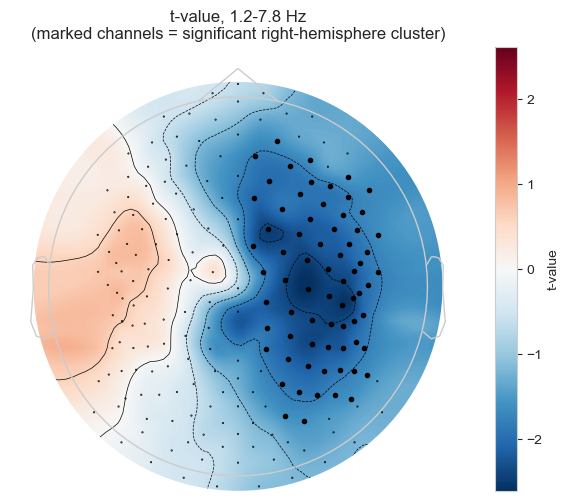

In [14]:
best = secondary_clusters[0]
members = best["members"]
ci_cluster, fi_cluster = np.unravel_index(members, (n_ch_roi, n_freq_roi))
cluster_ch_local = np.unique(ci_cluster)
cluster_ch_global = right_idx[cluster_ch_local]   # map back to the full 204-channel indexing
cluster_freq_range = (freqs[freq_idx][fi_cluster].min(), freqs[freq_idx][fi_cluster].max())

# Average t-value per channel over the cluster's frequency range, using the
# PRIMARY (whole-head, all real channels) map — so both hemispheres show
# real data; only the significant channels (right hemisphere) are marked.
freq_mask_cluster = (freqs >= cluster_freq_range[0]) & (freqs <= cluster_freq_range[1])
t_avg_full = t_obs_primary[:, freq_mask_cluster].mean(axis=1)

info_full = mne.create_info(ch_names, sfreq=1.0, ch_types="eeg")
info_full.set_montage(montage)

fig_topo, ax = plt.subplots(figsize=(6, 5))
mask = np.zeros(n_ch, dtype=bool)
mask[cluster_ch_global] = True
im, _ = mne.viz.plot_topomap(t_avg_full, info_full, axes=ax, show=False, cmap="RdBu_r",
                              mask=mask, mask_params=dict(marker="o", markerfacecolor="k",
                                                           markeredgecolor="k", markersize=3))
ax.set_title(f"t-value, {cluster_freq_range[0]:.1f}-{cluster_freq_range[1]:.1f} Hz\n"
             "(marked channels = significant right-hemisphere cluster)")
plt.colorbar(im, ax=ax, label="t-value")
plt.tight_layout()
plt.show()

### 2.6 Illustrative check: PSD by MoCA level

Purely for illustration (not a separate statistical test), we split
participants by a median MoCA split and plot the average spectrum at the
cluster's channels for each group.

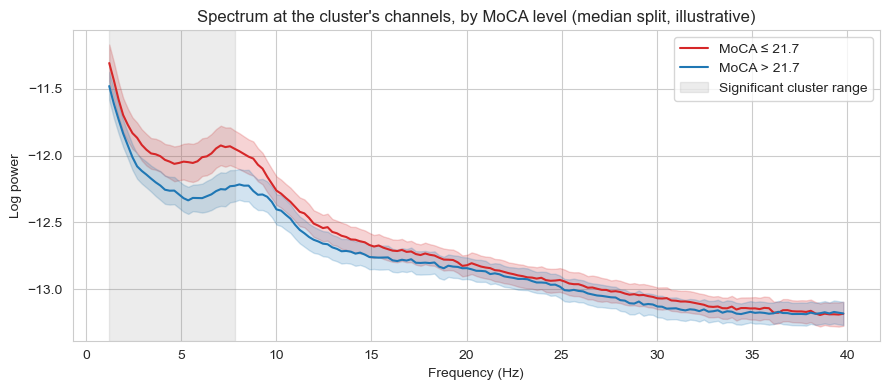

In [15]:
median_moca = np.median(moca)
low_group = moca <= median_moca
high_group = ~low_group

psd_cluster_ch = psd_log[:, right_idx][:, cluster_ch_local, :].mean(axis=1)  # avg over cluster channels

fig_bygroup, ax = plt.subplots(figsize=(9, 4))
for group, label, color in [(low_group, f"MoCA ≤ {median_moca:.1f}", "C3"),
                             (high_group, f"MoCA > {median_moca:.1f}", "C0")]:
    mean_curve = psd_cluster_ch[group].mean(axis=0)
    sem_curve = psd_cluster_ch[group].std(axis=0) / np.sqrt(group.sum())
    ax.plot(freqs, mean_curve, color=color, label=label)
    ax.fill_between(freqs, mean_curve - sem_curve, mean_curve + sem_curve, color=color, alpha=0.2)
ax.axvspan(cluster_freq_range[0], cluster_freq_range[1], color="gray", alpha=0.15,
           label="Significant cluster range")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Log power")
ax.set_title("Spectrum at the cluster's channels, by MoCA level (median split, illustrative)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.7 Exploratory: which canonical band drives the effect?

The secondary analysis above pools delta and theta (1–8 Hz) into a single
test. It is natural to ask whether the effect is really carried by both,
or mainly by one of them — and whether it is genuinely absent in
alpha/beta/gamma, as the clinical hypothesis would predict.

**This is an exploratory, supplementary analysis, not a substitute for
the pre-registered primary/secondary tests above.** We repeat the same
cluster-permutation procedure (same right-hemisphere ROI, same
threshold) separately for each of the five canonical bands. Because this
means testing **five** hypotheses instead of one, we apply a Bonferroni
correction across bands (multiply each band's p-value by 5, capped at 1)
— exactly the kind of correction Case Study 1 discussed for multiple
outcomes, applied here to multiple frequency bands instead.

In [16]:
CANONICAL_BANDS = {
    "delta": (1, 4), "theta": (4, 8), "alpha": (8, 13),
    "beta": (13, 30), "gamma": (30, 40),
}

band_results = {}
for band_name, (lo, hi) in CANONICAL_BANDS.items():
    band_freq_mask = (freqs >= lo) & (freqs < hi)
    band_freq_idx = np.where(band_freq_mask)[0]
    n_freq_band = len(band_freq_idx)
    band_adjacency = mne.stats.combine_adjacency(roi_spatial_adjacency, n_freq_band).tocsr()
    psd_log_band = psd_log[:, right_idx][:, :, band_freq_idx]

    clusters_band, t_obs_band = cluster_permutation_test(
        psd_log_band, moca, age, criq, band_adjacency, n_ch_roi, n_freq_band,
        t_thresh=T_THRESH, n_perm=N_PERM, seed=1)
    band_results[band_name] = {
        "freq_range": (lo, hi), "clusters": clusters_band, "t_obs": t_obs_band,
        "freq_idx": band_freq_idx,
    }

    top = clusters_band[0] if clusters_band else {"mass": 0.0, "members": np.array([], dtype=int), "p_cluster": 1.0}
    p_bonferroni = min(top["p_cluster"] * len(CANONICAL_BANDS), 1.0)
    band_results[band_name]["p_bonferroni"] = p_bonferroni
    print(f"{band_name:6s} ({lo:>2d}-{hi:>2d} Hz): mass={top['mass']:8.1f}  "
          f"size={len(top['members']):5d}  p_raw={top['p_cluster']:.3f}  "
          f"p_bonferroni={p_bonferroni:.3f}")

delta  ( 1- 4 Hz): mass=  -494.3  size=  221  p_raw=0.076  p_bonferroni=0.380


theta  ( 4- 8 Hz): mass= -1963.3  size=  827  p_raw=0.027  p_bonferroni=0.135


alpha  ( 8-13 Hz): mass=  -897.3  size=  393  p_raw=0.086  p_bonferroni=0.430


beta   (13-30 Hz): mass= -3378.2  size= 1421  p_raw=0.075  p_bonferroni=0.375


gamma  (30-40 Hz): mass= -1044.0  size=  444  p_raw=0.123  p_bonferroni=0.615


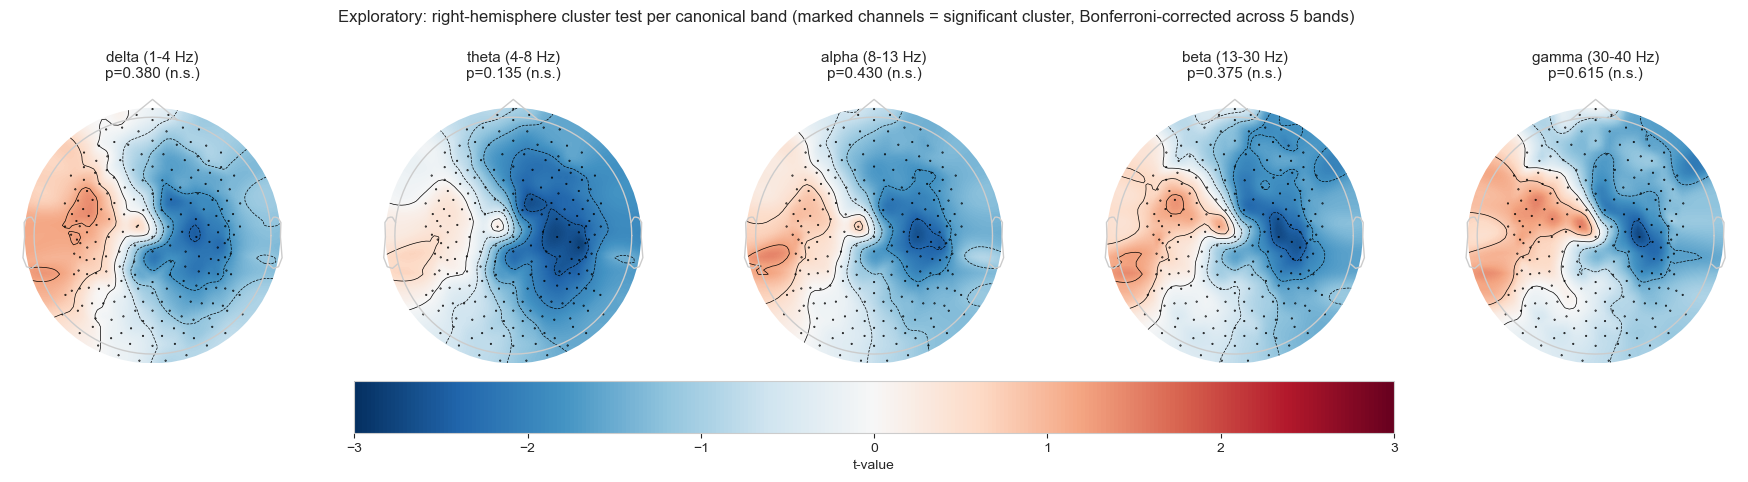

In [17]:
fig_bands, axes = plt.subplots(1, len(CANONICAL_BANDS), figsize=(4.5 * len(CANONICAL_BANDS), 4.5))

for ax, (band_name, res) in zip(axes, band_results.items()):
    lo, hi = res["freq_range"]
    # average t-value per channel across this band, from the whole-head
    # (204-channel) primary map, so every panel shows real bilateral data
    band_mask_full = (freqs >= lo) & (freqs < hi)
    t_avg_band = t_obs_primary[:, band_mask_full].mean(axis=1)

    top = res["clusters"][0] if res["clusters"] else None
    mask = np.zeros(n_ch, dtype=bool)
    if top is not None and res["p_bonferroni"] < 0.05:
        ci_band, _ = np.unravel_index(top["members"], (n_ch_roi, len(res["freq_idx"])))
        mask[right_idx[np.unique(ci_band)]] = True

    im, _ = mne.viz.plot_topomap(t_avg_band, info_full, axes=ax, show=False, cmap="RdBu_r",
                                  vlim=(-3, 3),
                                  mask=mask, mask_params=dict(marker="o", markerfacecolor="k",
                                                               markeredgecolor="k", markersize=3))
    sig_tag = "significant" if res["p_bonferroni"] < 0.05 else "n.s."
    ax.set_title(f"{band_name} ({lo}-{hi} Hz)\np={res['p_bonferroni']:.3f} ({sig_tag})", fontsize=11)

fig_bands.colorbar(im, ax=axes, label="t-value", shrink=0.7, location="bottom", pad=0.05)
fig_bands.suptitle("Exploratory: right-hemisphere cluster test per canonical band "
                    "(marked channels = significant cluster, Bonferroni-corrected across 5 bands)",
                    y=1.05)
plt.show()

In [18]:
table4_bands_rows = []
for band_name, res in band_results.items():
    lo, hi = res["freq_range"]
    top = res["clusters"][0] if res["clusters"] else {"mass": 0.0, "members": np.array([], dtype=int), "p_cluster": 1.0}
    table4_bands_rows.append({
        "Band": band_name, "Freq min (Hz)": lo, "Freq max (Hz)": hi,
        "Cluster mass": top["mass"], "N points": len(top["members"]),
        "p_raw": top["p_cluster"], "p_bonferroni (x5)": res["p_bonferroni"],
        "Significant (p<0.05)": res["p_bonferroni"] < 0.05,
    })
table4_bands = pd.DataFrame(table4_bands_rows)
table4_bands

,Band,Freq min (Hz),Freq max (Hz),Cluster mass,N points,p_raw,p_bonferroni (x5),Significant (p<0.05)
0,delta,1,4,-494.290573,221,0.076,0.380,False
1,theta,4,8,-1963.327835,827,0.027,0.135,False
2,alpha,8,13,-897.286565,393,0.086,0.430,False
3,beta,13,30,-3378.161142,1421,0.075,0.375,False
4,gamma,30,40,-1043.985072,444,0.123,0.615,False


> **What do we see in the plots?**
>
> Each panel is one canonical band, coloured by the same t-value scale;
> a panel's channels would be marked if that band's cluster survived
> correction for having tested five bands. This is a noticeably messier
> picture than a clean "low frequencies yes, high frequencies no" split:
> **none of the five individual bands survives Bonferroni correction**
> (theta comes closest, at a raw p≈0.03 that is no longer below 0.05
> once multiplied by 5), even though several bands show the same
> right-lateralised, negative direction as the pre-registered secondary
> test above.
>
> This is a more informative result than a clean split would have been,
> for two reasons. First, it is a direct, concrete illustration of why
> multiple-comparison correction matters: taken on its own, theta's raw
> p-value would look like a finding — it only stops looking like one once
> we account for having tested five bands instead of pre-committing to
> one. Second, it shows why the secondary analysis pooled delta and theta
> together rather than testing them separately: combining adjacent
> frequency bins into one wider band gives the cluster more points to
> draw statistical mass from, which is exactly what recovers the
> significant result there. Splitting the spectrum into ever-narrower
> slices trades away the power that made the pooled test work in the
> first place — the same lesson Case Study 1 taught about predictors,
> now shown for frequency bands.

---
## 3. Export

Same philosophy as Case Study 1: figures as PNG, tables as both CSV and
a single Excel workbook.

In [19]:
figures_to_save = {
    "A_grand_average_psd.png": fig_grandavg,
    "B_log_power_distributions.png": fig_dist,
    "C_uncorrected_tmap.png": fig_tmap,
    "D_cluster_topography.png": fig_topo,
    "E_psd_by_moca_level.png": fig_bygroup,
    "F_band_topographies.png": fig_bands,
}
for filename, fig in figures_to_save.items():
    path = FIGS / filename
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

Saved: outputs/figures/A_grand_average_psd.png
Saved: outputs/figures/B_log_power_distributions.png
Saved: outputs/figures/C_uncorrected_tmap.png


Saved: outputs/figures/D_cluster_topography.png
Saved: outputs/figures/E_psd_by_moca_level.png


Saved: outputs/figures/F_band_topographies.png


In [20]:
def clusters_to_table(clusters, freqs_, w_right_, ch_index_map, label):
    rows = []
    for rank, c in enumerate(clusters, start=1):
        ci, fi = np.unravel_index(c["members"], (len(ch_index_map), len(freqs_)))
        rows.append({
            "Analysis": label,
            "Cluster rank": rank,
            "Cluster mass": c["mass"],
            "N points": len(c["members"]),
            "Freq min (Hz)": freqs_[fi].min(),
            "Freq max (Hz)": freqs_[fi].max(),
            "Mean w_right": w_right_[[ch_index_map[i] for i in np.unique(ci)]].mean(),
            "p_cluster": c["p_cluster"],
        })
    return pd.DataFrame(rows)

table2_clusters = pd.concat([
    clusters_to_table(primary_clusters, freqs, w_right, np.arange(n_ch), "Primary (whole spectrum)"),
    clusters_to_table(secondary_clusters, freqs[freq_idx], w_right, right_idx, "Secondary (right hemisphere x 1-8 Hz)"),
], ignore_index=True)
table2_clusters

,Analysis,Cluster rank,Cluster mass,N points,Freq min (Hz),Freq max (Hz),Mean w_right,p_cluster
0,Primary (whole spectrum),1,-4620.506215,1954,15.869141,39.794922,0.859705,0.1940
1,Primary (whole spectrum),2,-3512.153969,1514,1.220703,15.380859,0.886845,0.2340
2,Primary (whole spectrum),3,-20.911310,10,14.648438,15.380859,0.978843,0.7695
3,Primary (whole spectrum),4,-15.193584,7,28.076172,29.541016,0.969307,0.7910
4,Primary (whole spectrum),5,-10.544509,5,19.287109,19.775391,0.871154,0.8180
5,Secondary (right hemisphere x 1-8 Hz),1,-2457.618408,1048,1.220703,7.812500,0.911069,0.0390


In [21]:
table3_baseline = pd.DataFrame({
    "Predictor": mod_baseline.params.index,
    "Estimate": mod_baseline.params.values,
    "Std. Error": mod_baseline.bse.values,
    "p-value": mod_baseline.pvalues.values,
})
table3_baseline["Significant (p<0.05)"] = table3_baseline["p-value"] < 0.05
table3_baseline

,Predictor,Estimate,Std. Error,p-value,Significant (p<0.05)
0,Intercept,29.783580,15.156964,0.049413,True
1,p300_amp,-0.316378,0.571789,0.580049,False
2,age,-0.178927,0.118331,0.130511,False
3,criq,0.077564,0.089823,0.387848,False


In [22]:
tables_to_save = {
    "table1_descriptives.csv": table1,
    "table2_clusters.csv": table2_clusters,
    "table3_baseline_model.csv": table3_baseline,
    "table4_band_breakdown.csv": table4_bands,
}
for filename, table in tables_to_save.items():
    path = RESULTS / filename
    table.to_csv(path, index=False)
    print(f"Saved: {path}")

xlsx_path = RESULTS / "CaseStudy_2_results.xlsx"
with pd.ExcelWriter(xlsx_path) as writer:
    table1.to_excel(writer, sheet_name="Descriptives", index=False)
    table2_clusters.to_excel(writer, sheet_name="Clusters", index=False)
    table3_baseline.to_excel(writer, sheet_name="Baseline model", index=False)
    table4_bands.to_excel(writer, sheet_name="Band breakdown", index=False)
print(f"Saved: {xlsx_path}")

Saved: outputs/results/table1_descriptives.csv
Saved: outputs/results/table2_clusters.csv
Saved: outputs/results/table3_baseline_model.csv
Saved: outputs/results/table4_band_breakdown.csv
Saved: outputs/results/CaseStudy_2_results.xlsx


---
## 4. Strengths and limitations of this approach (Section 4.2.3)

**Strengths:**
- No a priori commitment to a specific band or region — able to recover a
  **distributed, low-frequency, right-hemisphere pattern** that no single
  ERP feature (Case Study 1) would capture (Section 2.2 above)
- Respects the real spatial and spectral dependency structure of the
  signal, unlike testing every point independently

**Limitations:**
- **Computationally heavier** than the GLM-based approach of Case Study 1
- **Statistically demanding**: with around forty participants,
  cluster-based permutation is relatively underpowered, so only fairly
  marked associations are likely to survive — the whole-spectrum
  (primary) test in Section 2.4 illustrates this directly
- A significant *secondary* result depends on having pre-registered the
  restricted region **before** looking at the data; restricting only
  after seeing what "worked" would be the same circular reasoning
  Case Study 1 warned against, just at the level of search space instead
  of predictor selection

> For a full discussion, see Section 4.2 of the companion paper, and
> Section 5.1 on general caveats (multiple comparisons, and not equating
> analytical complexity with validity).

---

*Notebook generated for the EEG-NPSI tutorial. All code is self-contained
for transparency and reproducibility.*